# 05 — Bivariate Relationships
**Goal:** Visualize how two variables move together — scatter, line, bar,
area, hexbin. Most growth-analytics charts live here.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(11)
print('numpy', np.__version__)

numpy 2.5.0


## 1. The scatter — the workhorse

Scatter plots answer *"is there a relationship between x and y, and what
shape is it?"* — linear, curved, clustered, heteroscedastic.

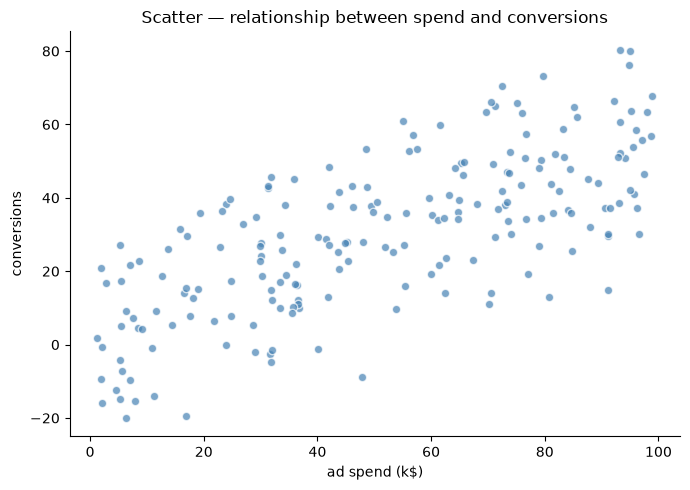

In [2]:
n = 200
x = np.random.uniform(0, 100, n)
y = 0.6 * x + np.random.normal(0, 15, n)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.7, color='steelblue', edgecolor='white')
ax.set_xlabel('ad spend (k$)'); ax.set_ylabel('conversions')
ax.set_title('Scatter — relationship between spend and conversions')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Add a regression line

Always pair a scatter with a fitted line when the reader is asked to evaluate a
trend. The line is the *claim*; the scatter is the *evidence*.

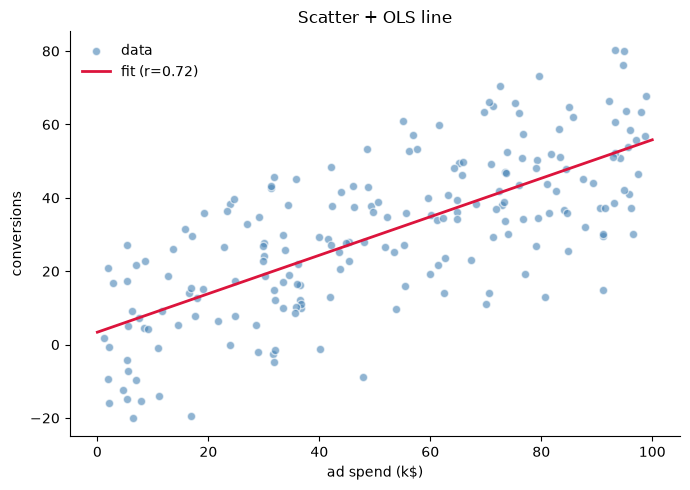

In [3]:
slope, intercept, r, *_ = __import__('scipy.stats', fromlist=['linregress']).linregress(x, y)
x_line = np.linspace(0, 100, 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.6, color='steelblue', edgecolor='white', label='data')
ax.plot(x_line, y_line, color='crimson', lw=2, label=f'fit (r={r:.2f})')
ax.set_xlabel('ad spend (k$)'); ax.set_ylabel('conversions')
ax.legend(frameon=False)
ax.set_title('Scatter + OLS line')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Encoding a third variable

Color (hue) for a category, size for a continuous variable, shape for a second
category. The classic *bubble chart*.

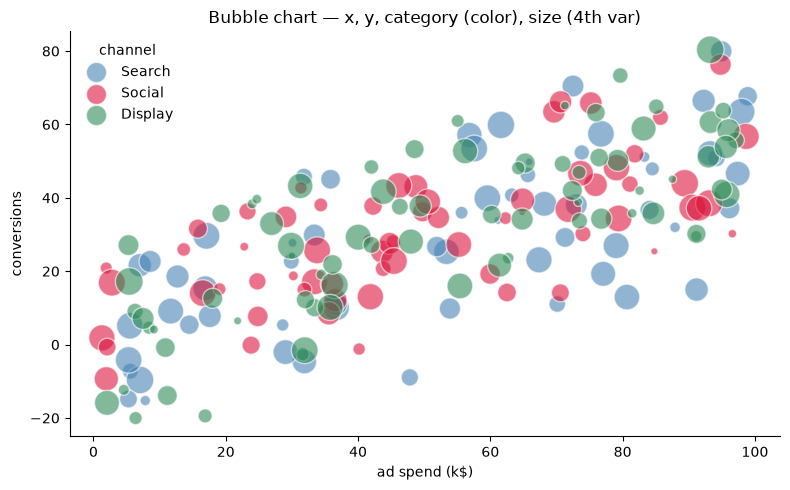

In [4]:
channel = np.random.choice(['Search', 'Social', 'Display'], n)
size    = np.random.uniform(20, 400, n)
colors  = {'Search': 'steelblue', 'Social': 'crimson', 'Display': 'seagreen'}

fig, ax = plt.subplots(figsize=(8, 5))
for ch in colors:
    mask = channel == ch
    ax.scatter(x[mask], y[mask], s=size[mask], alpha=0.6,
               color=colors[ch], label=ch, edgecolor='white')
ax.set_xlabel('ad spend (k$)'); ax.set_ylabel('conversions')
ax.legend(frameon=False, title='channel')
ax.set_title('Bubble chart — x, y, category (color), size (4th var)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Hexbin — when scatter turns into a blob

Past a few thousand points, scatter becomes a wall of ink. Hexbin groups
points into hexagonal bins and colors them by count.

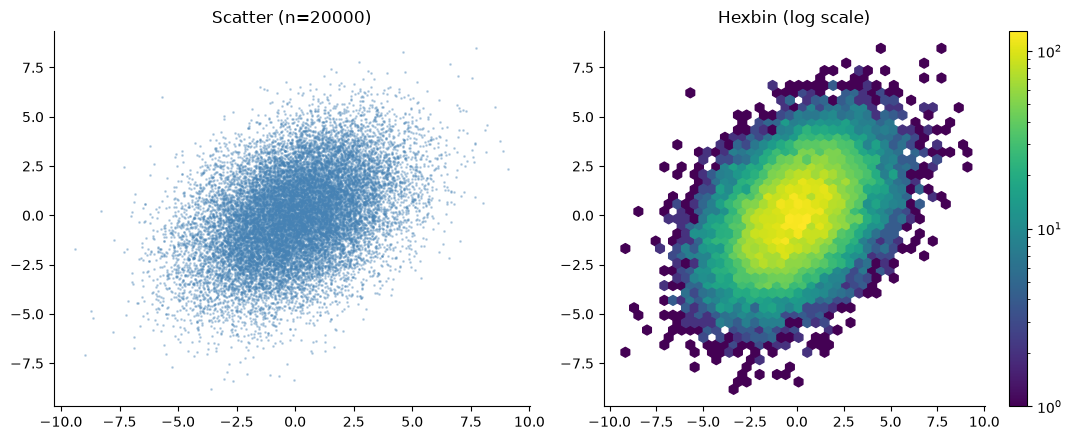

In [5]:
from matplotlib.colors import LogNorm
big = np.random.multivariate_normal([0, 0], [[5, 2], [2, 5]], 20_000)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(big[:, 0], big[:, 1], s=1, alpha=0.3, color='steelblue')
axes[0].set_title(f'Scatter (n={len(big)})')
hb = axes[1].hexbin(big[:, 0], big[:, 1], gridsize=40, cmap='viridis', norm=LogNorm())
fig.colorbar(hb, ax=axes[1])
axes[1].set_title('Hexbin (log scale)')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Line plots — change over an ordered x

Use line plots when:

- x is **ordered** (time, dose, distance) AND
- y is **continuous** AND
- the line between points has meaning (a *trajectory*).

Do **not** connect categorical groups with a line — the slope is meaningless.

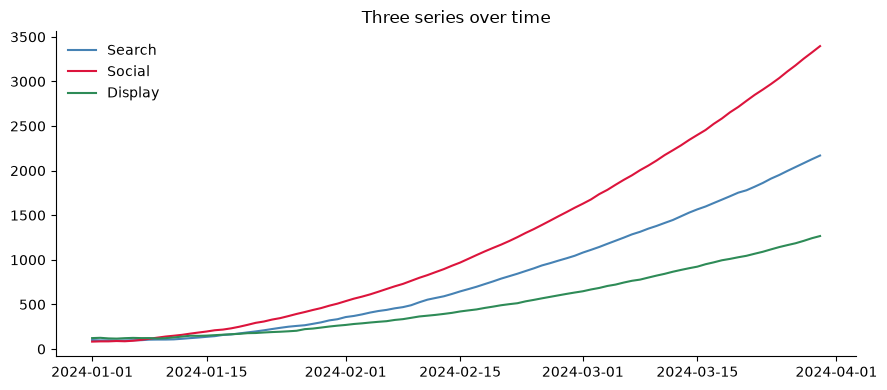

In [6]:
dates = pd.date_range('2024-01-01', periods=90, freq='D')
y1 = (dates.dayofyear.to_numpy() * 0.5 + np.random.normal(0, 4, 90)).cumsum() + 100
y2 = (dates.dayofyear.to_numpy() * 0.8 + np.random.normal(0, 4, 90)).cumsum() + 80
y3 = (dates.dayofyear.to_numpy() * 0.3 + np.random.normal(0, 4, 90)).cumsum() + 120

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dates, y1, label='Search',   color='steelblue')
ax.plot(dates, y2, label='Social',   color='crimson')
ax.plot(dates, y3, label='Display',  color='seagreen')
ax.set_title('Three series over time')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Bar vs Lollipop vs Dot

For categorical comparison, bars are familiar but dominate visually. Lollipops
and Cleveland dots give the same comparison with less ink.

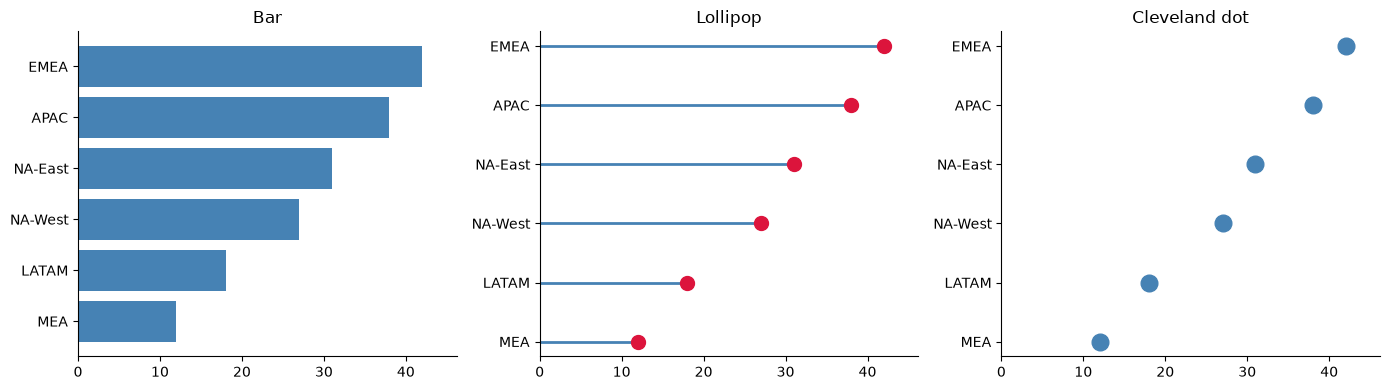

In [7]:
categories = ['EMEA', 'APAC', 'NA-East', 'NA-West', 'LATAM', 'MEA']
values     = [42, 38, 31, 27, 18, 12]
order      = np.argsort(values)
categories = [categories[i] for i in order]
values     = [values[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].barh(categories, values, color='steelblue')
axes[0].set_title('Bar')

axes[1].hlines(categories, 0, values, color='steelblue', lw=2)
axes[1].plot(values, categories, 'o', color='crimson', markersize=10)
axes[1].set_title('Lollipop')

axes[2].plot(values, categories, 'o', color='steelblue', markersize=12)
axes[2].set_title('Cleveland dot')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, max(values) * 1.1)
plt.tight_layout(); plt.show()

## 7. Stacked vs grouped bars

- **Stacked** for part-to-whole *and* total.
- **Grouped** for direct comparison between categories.
- **100% stacked** for part-to-whole when totals are uneven.

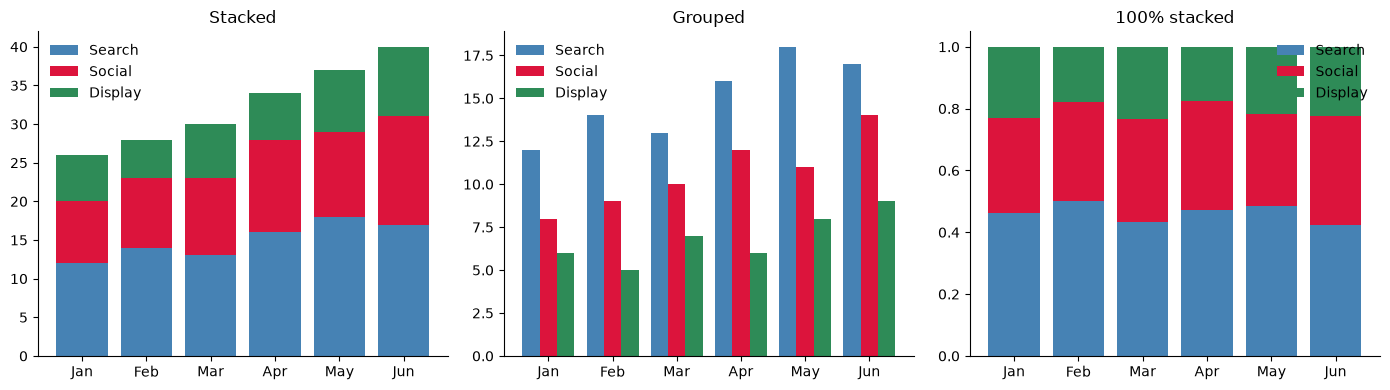

In [8]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
search = [12, 14, 13, 16, 18, 17]
social = [ 8,  9, 10, 12, 11, 14]
display= [ 6,  5,  7,  6,  8,  9]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(months, search, color='steelblue', label='Search')
axes[0].bar(months, social, bottom=search, color='crimson', label='Social')
axes[0].bar(months, display, bottom=np.array(search)+np.array(social),
            color='seagreen', label='Display')
axes[0].set_title('Stacked'); axes[0].legend(frameon=False)

x = np.arange(len(months)); w = 0.27
axes[1].bar(x-w, search,  width=w, color='steelblue', label='Search')
axes[1].bar(x,   social,  width=w, color='crimson',  label='Social')
axes[1].bar(x+w, display, width=w, color='seagreen', label='Display')
axes[1].set_xticks(x); axes[1].set_xticklabels(months)
axes[1].set_title('Grouped'); axes[1].legend(frameon=False)

tot = np.array(search) + np.array(social) + np.array(display)
axes[2].bar(months, search/tot,   color='steelblue', label='Search')
axes[2].bar(months, social/tot,   bottom=search/tot, color='crimson', label='Social')
axes[2].bar(months, display/tot,
            bottom=(np.array(search)+np.array(social))/tot, color='seagreen', label='Display')
axes[2].set_title('100% stacked'); axes[2].legend(frameon=False)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Area charts — magnitude + change

Use when both the **cumulative value** and the **change over x** matter. Be
careful: stacked area can mislead because the *top* series is plotted against
the *cumulative* baseline, not its own zero.

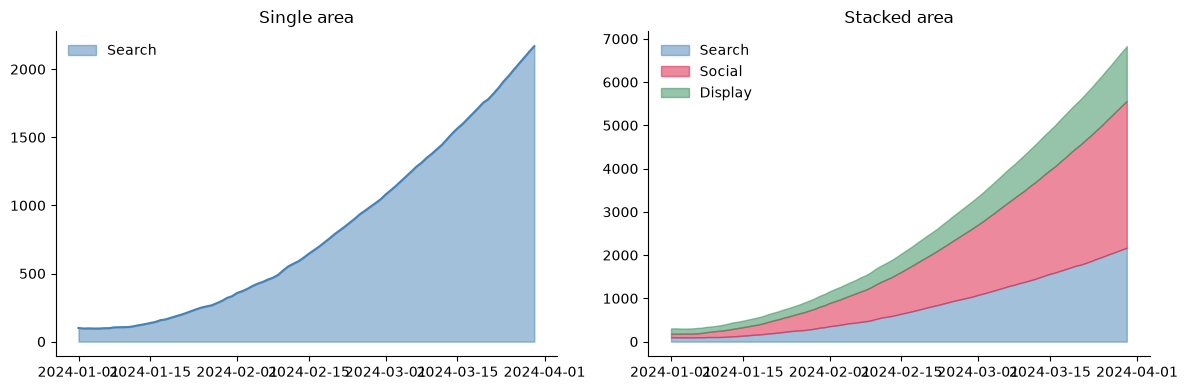

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].fill_between(dates, y1, color='steelblue', alpha=0.5, label='Search')
axes[0].plot(dates, y1, color='steelblue', lw=1.5)
axes[0].set_title('Single area')
axes[0].legend(frameon=False)

axes[1].fill_between(dates, 0, y1, color='steelblue', alpha=0.5, label='Search')
axes[1].fill_between(dates, y1, y1+y2, color='crimson', alpha=0.5, label='Social')
axes[1].fill_between(dates, y1+y2, y1+y2+y3, color='seagreen', alpha=0.5, label='Display')
axes[1].set_title('Stacked area')
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Slope — the underrated chart for before/after

When you have a before/after measurement per category, a slope chart is the
single best chart. It shows the *change* directly.

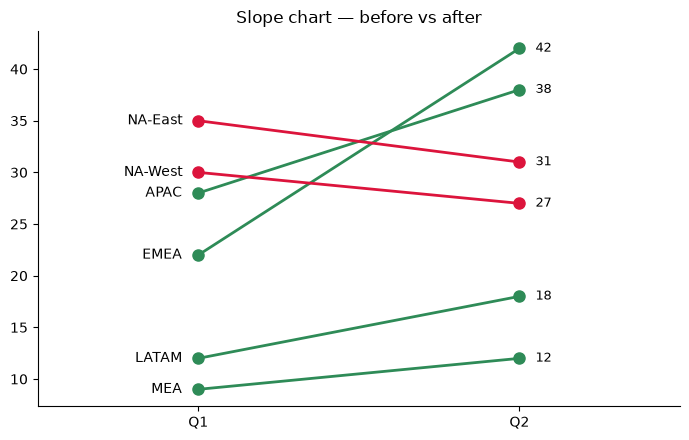

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ['EMEA', 'APAC', 'NA-East', 'NA-West', 'LATAM', 'MEA']
before = [22, 28, 35, 30, 12, 9]
after  = [42, 38, 31, 27, 18, 12]
for lab, b, a in zip(labels, before, after):
    color = 'seagreen' if a > b else 'crimson'
    ax.plot([0, 1], [b, a], color=color, lw=2, marker='o', markersize=8)
    ax.text(-0.05, b, lab, ha='right', va='center')
    ax.text(1.05, a,  str(a), ha='left',  va='center', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Q1', 'Q2'])
ax.set_xlim(-0.5, 1.5)
ax.set_title('Slope chart — before vs after')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 10. Real data — relationship exploration

End with a quick EDA pass on the unified marketing data.

In [11]:
df = pd.read_csv('data/clean/unified_daily.csv', parse_dates=['date'] if 'date' in pd.read_csv('data/clean/unified_daily.csv', nrows=0).columns else None)
print(df.dtypes.to_dict())

{'date': dtype('<M8[us]'), 'visits': dtype('int64'), 'activations': dtype('int64'), 'otp_total': dtype('int64'), 'spend': dtype('float64'), 'impressions': dtype('int64'), 'clicks': dtype('int64'), 'paid_conv': dtype('int64'), 'cvr': dtype('float64'), 'cpa': dtype('float64'), 'ctr': dtype('float64'), 'roas': dtype('float64'), 'paid_share': dtype('float64')}


Numeric columns: ['visits', 'activations', 'otp_total', 'spend', 'impressions', 'clicks', 'paid_conv', 'cvr']


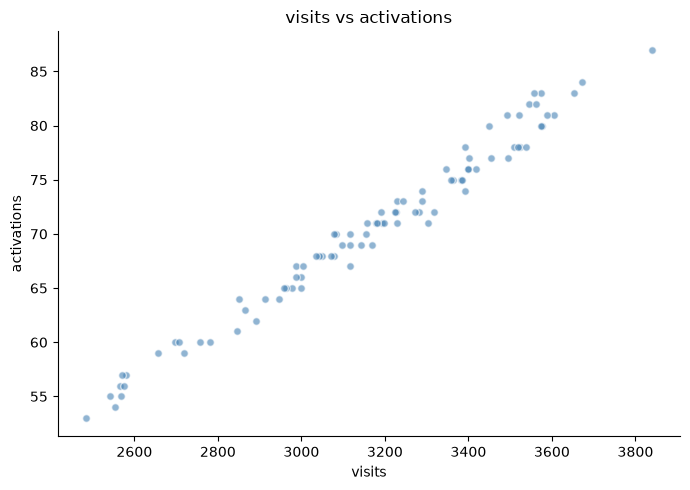

In [12]:
num = df.select_dtypes('number').columns.tolist()
print('Numeric columns:', num[:8])
if len(num) >= 2:
    a, b = num[0], num[1]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df[a], df[b], alpha=0.6, s=30, color='steelblue', edgecolor='white')
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f'{a} vs {b}')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout(); plt.show()

## Summary

| Chart | Best for |
|---|---|
| Scatter | Two continuous variables, any shape |
| Bubble | + category (color) + size (4th var) |
| Hexbin | Many points, two continuous variables |
| Line | Continuous y over ordered x (time, dose) |
| Bar / lollipop / dot | Categorical comparison |
| Stacked bar | Part-to-whole + total |
| Area | Magnitude + change |
| Slope | Before/after |

**Next:** `06_multivariate_composition.ipynb` — many variables at once.